# Notebook 01 — Extraction & Preprocessing
## FAO OED · Country Programme Evaluation · Morocco 2017–2020

**Project:** Deconstructing a FAO Evaluation Report — NLP & Evidence Mapping  
**Author:** Asma Boufaden  
**Goal:** Extract raw text from the FAO CPE Morocco PDF, segment it by evaluation section, clean and normalise the French-language corpus for downstream NLP analysis.

---
### What this notebook does
1. **Environment setup** — install required libraries
2. **PDF extraction** — extract raw text page by page using `pdfplumber`
3. **Section mapping** — segment the report using confirmed page boundaries from the Table of Contents
4. **Text cleaning** — remove headers/footers, fix page-break artefacts, normalise whitespace
5. **NLP preprocessing** — tokenise and remove French stopwords using `nltk`
6. **Frequency analysis** — top terms per section
7. **Export** — save all outputs to `data/processed/` for use in notebooks 02–04

---
⚠️ **Transparency note:** Python code in this notebook was developed with AI-assisted tools (Claude AI, Microsoft Copilot). All outputs, interpretations, and conclusions were verified, reviewed and validated by the author. This reflects standard practice in modern data science workflows.

---
### Note on section boundaries
The FAO CPE Morocco PDF uses two page numbering systems:
- Pages 1–10 of the PDF file = cover, acknowledgements, acronyms (roman numerals in print)
- Page 11 of the PDF = page ix in print (Résumé exécutif) — **offset of +10 pages**

Section boundaries below are **PDF file page numbers**, confirmed by scanning the Table of Contents (pages 7–8 of the PDF).

## 0. Environment setup
Run this cell **once**, then **restart your kernel** before proceeding.

In [9]:
import subprocess, sys, os, shutil
from pathlib import Path

# Step 1 — install packages
packages = ['pdfplumber', 'nltk', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'tqdm']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import nltk

# Step 2 — delete corrupted NLTK data files if they exist
nltk_data_dir = Path(nltk.data.path[0])
for folder in ['tokenizers/punkt', 'tokenizers/punkt_tab']:
    target = nltk_data_dir / folder
    if target.exists():
        shutil.rmtree(target)
        print(f'🗑️  Deleted corrupted: {target}')
    # Also delete zip if present
    zip_target = Path(str(target) + '.zip')
    if zip_target.exists():
        zip_target.unlink()
        print(f'🗑️  Deleted corrupted zip: {zip_target}')

# Step 3 — re-download cleanly
for resource in ['punkt', 'punkt_tab', 'stopwords']:
    result = nltk.download(resource, quiet=False)
    print(f'{"✅" if result else "❌"} {resource}')

print('\n✅ Done. Restart your kernel now.')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\abouf\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\abouf\AppData\Roaming\nltk_data...


✅ punkt


[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


✅ punkt_tab
✅ stopwords

✅ Done. Restart your kernel now.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abouf\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 1. Imports & configuration

In [2]:
!pip install pdfplumber
!pip install spacy
!pip install click
!pip install nltk
import pdfplumber
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import re
from pathlib import Path
from tqdm import tqdm
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# ── Paths — update PDF_PATH to match your folder structure ───────────────────
PDF_PATH      = Path("C:/Users/abouf/OneDrive/Desktop/DATA SCIENCE/GITHUB/FAO CPE/data/Rapport_Morocco.pdf")
PROCESSED_DIR = Path('../data/processed')
FIGURES_DIR   = Path('../outputs/figures')
RESULTS_DIR   = Path('../outputs/results')

for d in [PROCESSED_DIR, FIGURES_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('✅ Libraries loaded')
print(f'   PDF path : {PDF_PATH}')
print(f'   Exists   : {PDF_PATH.exists()}')

✅ Libraries loaded
   PDF path : C:\Users\abouf\OneDrive\Desktop\DATA SCIENCE\GITHUB\FAO CPE\data\Rapport_Morocco.pdf
   Exists   : True


> ⚠️ **If `Exists: False`** — update `PDF_PATH` above with the correct path to your PDF before continuing.

## 2. PDF extraction — raw text, page by page

In [14]:
def extract_pages(pdf_path):
    """Extract text from each page. Returns list of {page_num, text, char_count}."""
    pages = []
    with pdfplumber.open(pdf_path) as pdf:
        print(f'📄 Total pages in PDF: {len(pdf.pages)}')
        for i, page in enumerate(tqdm(pdf.pages, desc='Extracting')):
            text = page.extract_text() or ''
            pages.append({'page_num': i + 1, 'text': text, 'char_count': len(text)})
    return pages

pages = extract_pages(PDF_PATH)

total_chars = sum(p['char_count'] for p in pages)
empty_pages = [p['page_num'] for p in pages if p['char_count'] < 50]

print(f'\n📊 Extraction summary')
print(f'   Total pages    : {len(pages)}')
print(f'   Total chars    : {total_chars:,}')
print(f'   Empty pages    : {empty_pages if empty_pages else "none"}')
print(f'   Avg chars/page : {total_chars // len(pages):,}')

📄 Total pages in PDF: 104


Extracting: 100%|██████████| 104/104 [00:20<00:00,  5.18it/s]


📊 Extraction summary
   Total pages    : 104
   Total chars    : 299,174
   Empty pages    : [2, 6, 16, 24, 32, 38, 48, 70, 78, 84, 103]
   Avg chars/page : 2,876


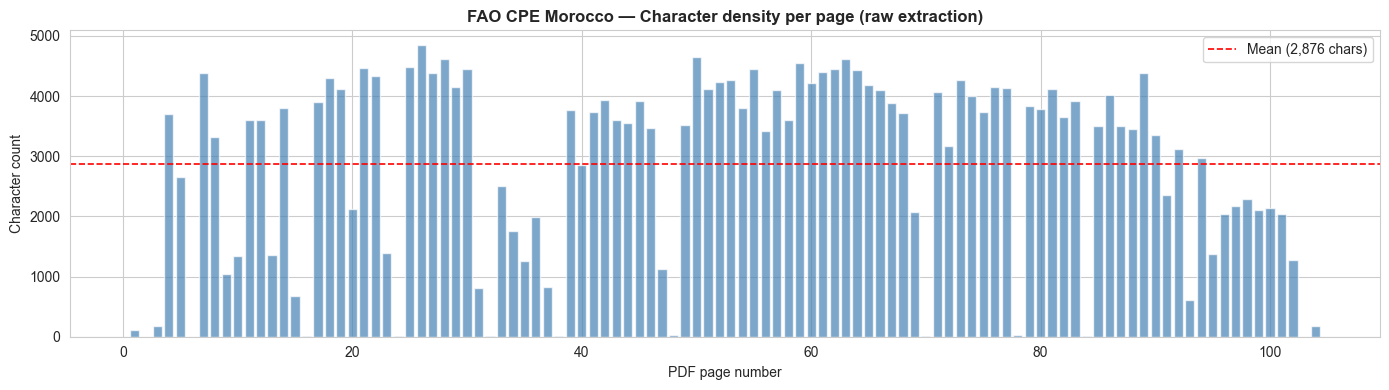

💾 Saved: outputs/figures/page_density.png


In [15]:
# Visual: character density per page
fig, ax = plt.subplots(figsize=(14, 4))
page_nums   = [p['page_num'] for p in pages]
char_counts = [p['char_count'] for p in pages]

ax.bar(page_nums, char_counts, color='steelblue', alpha=0.7, width=0.8)
ax.axhline(np.mean(char_counts), color='red', linestyle='--',
           linewidth=1.2, label=f'Mean ({int(np.mean(char_counts)):,} chars)')
ax.set_xlabel('PDF page number')
ax.set_ylabel('Character count')
ax.set_title('FAO CPE Morocco — Character density per page (raw extraction)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'page_density.png', dpi=150)
plt.show()
print('💾 Saved: outputs/figures/page_density.png')

## 3. Section mapping

Section boundaries are **confirmed from the Table of Contents** (PDF pages 7–8) and validated by direct page inspection.

The notation `(start, end)` means: collect pages where `start ≤ page_num < end`.

| Section | PDF pages | Print pages | Notes |
|---------|-----------|-------------|-------|
| Résumé exécutif | 11–14 | ix | |
| 1. Introduction | 15–24 | 1–8 | |
| 2. Contexte | 25–32 | 9–... | |
| 3. La FAO au Maroc | 33–38 | | Portfolio overview |
| 4. Pertinence | 39–48 | | OECD/DAC criterion |
| 5. Contributions aux résultats | 49–70 | | Main findings body |
| 6. Effet catalytique | 71–78 | | |
| 7. Conclusions | 79–84 | 63+ | |
| 8. Recommandations | 85–92 | 69+ | |
| Annexes | 93–105 | 76+ | ToR, interviewees, bibliography |

In [16]:
# Confirmed section boundaries (PDF page numbers)
SECTION_MAP = {
    'resume_executif'            : (11, 15),
    'introduction'               : (15, 25),
    'contexte_pays'              : (25, 33),
    'fao_maroc_portfolio'        : (33, 39),
    'pertinence'                 : (39, 49),
    'contributions_resultats'    : (49, 71),
    'effet_catalytique'          : (71, 79),
    'conclusions'                : (79, 85),
    'recommandations'            : (85, 93),
    'annexes'                    : (93, 106),
}


def build_sections(pages, section_map):
    """
    Aggregate page text into sections using confirmed PDF page boundaries.
    Returns dict: {section_name: raw_text}
    """
    sections = {}
    for name, (start, end) in section_map.items():
        text = ' '.join(
            p['text'] for p in pages
            if start <= p['page_num'] < end
        )
        sections[name] = text
    return sections


sections_raw = build_sections(pages, SECTION_MAP)

print('📑 Sections built from confirmed PDF page boundaries:')
print(f'{"Section":<30} {"PDF pages":>12} {"Words":>10}')
print('-' * 57)
for name, (start, end) in SECTION_MAP.items():
    words = len(sections_raw[name].split())
    print(f'{name:<30} {str(start)+"–"+str(end-1):>12} {words:>10,}')

📑 Sections built from confirmed PDF page boundaries:
Section                           PDF pages      Words
---------------------------------------------------------
resume_executif                       11–14      1,855
introduction                          15–24      3,845
contexte_pays                         25–32      4,183
fao_maroc_portfolio                   33–38      1,298
pertinence                            39–48      4,597
contributions_resultats               49–70     12,966
effet_catalytique                     71–78      4,136
conclusions                           79–84      2,971
recommandations                       85–92      4,048
annexes                              93–105      2,575


## 4. Text cleaning

In [17]:
def clean_text(text):
    """
    Clean extracted PDF text:
    - Fix hyphenated line-break splits (e.g. 'évalu-\nation' → 'évaluation')
    - Remove standalone page numbers
    - Remove page-break artefacts: repeated running chapter headers
    - Remove isolated capitalised words inserted at page boundaries
    - Normalise whitespace
    """
    # Fix hyphenated line breaks
    text = re.sub(r'(\w+)-\n(\w+)', r'\1\2', text)

    # Remove standalone page numbers (digit-only lines)
    text = re.sub(r'\n\s*\d{1,3}\s*\n', '\n', text)

    # Remove page-break artefacts: running chapter headers (e.g. "3. La FAO au Maroc")
    text = re.sub(r'\n\d+\.\s+[A-ZÀÂÉÈÊËÎÏÔÙÛÜ][^\n]{5,60}\n', '\n', text)

    # Remove isolated capitalised words on their own line (page-break noise)
    text = re.sub(r'\n[A-ZÀÂÉÈÊËÎÏÔÙÛÜ][a-zàâéèêëîïôùûü]{2,25}\n', '\n', text)

    # Normalise whitespace
    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n{3,}', '\n\n', text)

    return text.strip()


sections_clean = {name: clean_text(text) for name, text in sections_raw.items()}

# Build and save full clean text
full_text_clean = '\n\n'.join(
    f'=== {name.upper().replace("_", " ")} ===\n{text}'
    for name, text in sections_clean.items()
)

with open(PROCESSED_DIR / 'full_text.txt', 'w', encoding='utf-8') as f:
    f.write(full_text_clean)

with open(PROCESSED_DIR / 'sections.json', 'w', encoding='utf-8') as f:
    json.dump(sections_clean, f, ensure_ascii=False, indent=2)

print('✅ Text cleaned and saved')
print('   data/processed/full_text.txt')
print('   data/processed/sections.json')

# Quick before/after sample
first_section = list(sections_clean.keys())[0]
print(f'\n--- Before cleaning ({first_section}, first 300 chars) ---')
print(list(sections_raw.values())[0][:300])
print(f'\n--- After cleaning ---')
print(list(sections_clean.values())[0][:300])

✅ Text cleaned and saved
   data/processed/full_text.txt
   data/processed/sections.json

--- Before cleaning (resume_executif, first 300 chars) ---
Résumé exécutif
Introduction
1 Le Cadre de programmation pays (CPP) du Maroc a été sélectionné pour une évaluation
visant à éclairer le processus de réflexion qui mènera à l’élaboration du nouveau cycle de
programmation du Système des Nations Unies au Maroc pour la période 2022-2026 et à
celle du no

--- After cleaning ---
Résumé exécutif
1 Le Cadre de programmation pays (CPP) du Maroc a été sélectionné pour une évaluation
visant à éclairer le processus de réflexion qui mènera à l’élaboration du nouveau cycle de
programmation du Système des Nations Unies au Maroc pour la période 2022-2026 et à
celle du nouveau CPP.
2 


## 5. NLP preprocessing — tokenisation & stopword removal

In [18]:
# French stopwords + evaluation-specific noise terms
FR_STOPS = set(stopwords.words('french'))
FR_STOPS |= {
    'fao', 'maroc', 'marocain', 'marocaine', 'programme', 'pays',
    'évaluation', 'evaluation', 'rapport', 'projet', 'activité',
    'résultat', 'résultats', 'cadre', 'national', 'nationale',
    'annexe', 'page', 'figure', 'tableau', 'notamment', 'ainsi',
    'dont', 'lors', 'entre', 'vers', 'plus', 'aussi', 'cette',
    'cet', 'tout', 'tous', 'très', 'bien', 'être', 'faire'
}


def preprocess_section(text, stops, min_len=3):
    """
    Tokenise French text using regex split (no punkt_tab dependency).
    Filters: alphabetic, min length 3, not in stopwords.
    """
    # Regex tokeniser — splits on non-alphabetic characters
    tokens = re.findall(r'\b[a-zA-ZÀ-ÿ]{3,}\b', text)
    return [
        t.lower() for t in tokens
        if t.lower() not in stops
        and len(t) >= min_len
    ]


def extract_sentences(text, min_len=30):
    """Split text into sentences, filter by minimum character length."""
    return [
        s.strip() for s in re.split(r'(?<=[.!?])\s+', text)
        if len(s.strip()) >= min_len
    ]


print('⚙️  Preprocessing sections...')
preprocessed  = {}
sentences_all = []

for name, text in tqdm(sections_clean.items(), desc='Sections'):
    tokens    = preprocess_section(text, FR_STOPS)
    sentences = extract_sentences(text)
    preprocessed[name] = {
        'tokens'         : tokens,
        'token_count'    : len(tokens),
        'sentences'      : sentences,
        'sentence_count' : len(sentences),
    }
    for sent in sentences:
        sentences_all.append({'section': name, 'sentence': sent})

print(f'\n✅ NLP preprocessing complete')
print(f'   Sections processed : {len(preprocessed)}')
print(f'   Total sentences    : {len(sentences_all):,}')
print(f'   Total tokens       : {sum(d["token_count"] for d in preprocessed.values()):,}')

⚙️  Preprocessing sections...


Sections: 100%|██████████| 10/10 [00:00<00:00, 404.48it/s]


✅ NLP preprocessing complete
   Sections processed : 10
   Total sentences    : 1,414
   Total tokens       : 20,954


In [19]:
# Summary table
summary = pd.DataFrame([
    {
        'Section'         : name,
        'Tokens'          : d['token_count'],
        'Sentences'       : d['sentence_count'],
        'Unique tokens'   : len(set(d['tokens'])),
        'Lexical density' : round(len(set(d['tokens'])) / max(d['token_count'], 1), 3),
    }
    for name, d in preprocessed.items()
])

print('📊 Preprocessing summary:')
print(summary.to_string(index=False))

📊 Preprocessing summary:
                Section  Tokens  Sentences  Unique tokens  Lexical density
        resume_executif     873         62            583            0.668
           introduction    1768        142            953            0.539
          contexte_pays    2094        119           1035            0.494
    fao_maroc_portfolio     635         41            340            0.535
             pertinence    2158        149           1046            0.485
contributions_resultats    6352        412           2283            0.359
      effet_catalytique    2039        153           1025            0.503
            conclusions    1408         99            783            0.556
        recommandations    2032        165           1015            0.500
                annexes    1595         72            702            0.440


## 6. Frequency analysis — top terms per key section

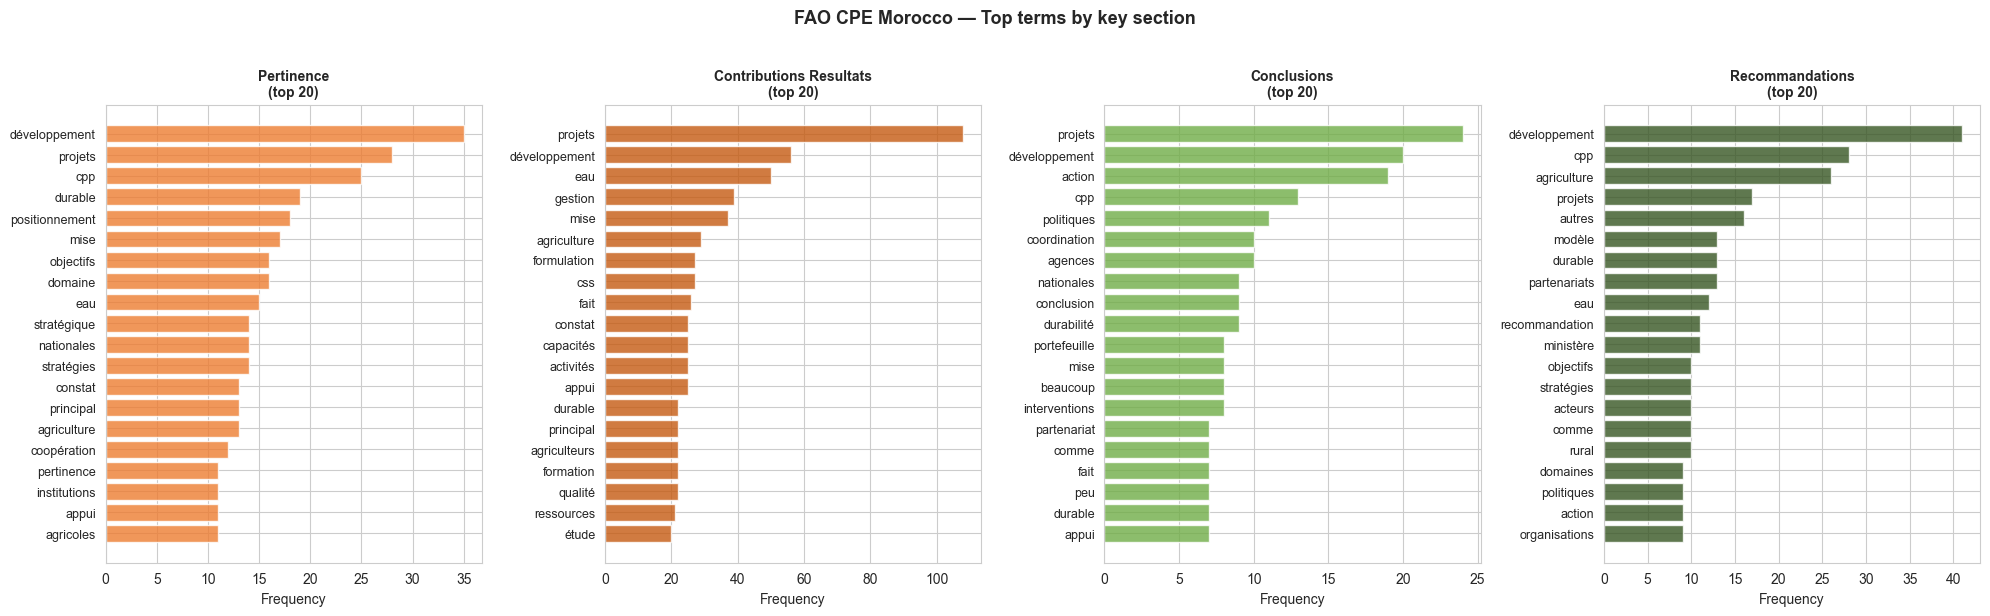

💾 Saved: outputs/figures/top_terms_by_section.png


In [20]:
KEY_SECTIONS = ['pertinence', 'contributions_resultats', 'conclusions', 'recommandations']
available    = [s for s in KEY_SECTIONS if s in preprocessed]

fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 6))
if len(available) == 1:
    axes = [axes]

SECTION_COLORS = {
    'pertinence'              : '#ED7D31',
    'contributions_resultats' : '#C55A11',
    'conclusions'             : '#70AD47',
    'recommandations'         : '#375623',
}

for ax, sec in zip(axes, available):
    counter = Counter(preprocessed[sec]['tokens'])
    top20   = counter.most_common(20)
    if not top20:
        ax.set_title(f'{sec}\n(no tokens)')
        continue
    words, counts = zip(*top20)
    y = range(len(words))
    ax.barh(y, counts, color=SECTION_COLORS.get(sec, 'steelblue'), alpha=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(words, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Frequency')
    ax.set_title(f'{sec.replace("_", " ").title()}\n(top 20)', fontsize=10, fontweight='bold')

plt.suptitle('FAO CPE Morocco — Top terms by key section', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_terms_by_section.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: outputs/figures/top_terms_by_section.png')

## 7. Export all processed data

In [21]:
# Export 1 — Sentences CSV (used by notebooks 02, 03, 04)
df_sentences = pd.DataFrame(sentences_all)
df_sentences.to_csv(PROCESSED_DIR / 'sentences.csv', index=False, encoding='utf-8')
print(f'💾 sentences.csv saved: {len(df_sentences):,} rows')

# Export 2 — Token lists per section (used by notebook 02 — topic modelling)
tokens_export = {name: data['tokens'] for name, data in preprocessed.items()}
with open(PROCESSED_DIR / 'tokens_by_section.json', 'w', encoding='utf-8') as f:
    json.dump(tokens_export, f, ensure_ascii=False, indent=2)
print('💾 tokens_by_section.json saved')

# Export 3 — Preprocessing summary
summary.to_csv(RESULTS_DIR / 'preprocessing_summary.csv', index=False)
print('💾 preprocessing_summary.csv saved')

# Export 4 — Section map with PDF page boundaries (used by notebooks 03, 04)
section_map_export = {name: {'start': s, 'end': e} for name, (s, e) in SECTION_MAP.items()}
with open(PROCESSED_DIR / 'section_map.json', 'w', encoding='utf-8') as f:
    json.dump(section_map_export, f, ensure_ascii=False, indent=2)
print('💾 section_map.json saved')

print('\n✅ Notebook 01 complete. All outputs saved.')
print('\nFiles in data/processed/')
print('  full_text.txt · sections.json · sentences.csv · tokens_by_section.json · section_map.json')
print('\nNext step → open 02_topic_modelling.ipynb')

💾 sentences.csv saved: 1,414 rows
💾 tokens_by_section.json saved
💾 preprocessing_summary.csv saved
💾 section_map.json saved

✅ Notebook 01 complete. All outputs saved.

Files in data/processed/
  full_text.txt · sections.json · sentences.csv · tokens_by_section.json · section_map.json

Next step → open 02_topic_modelling.ipynb


## 8. Troubleshooting

| Problem | Likely cause | Fix |
|---------|-------------|-----|
| `Exists: False` | Wrong PDF path | Update `PDF_PATH` in cell 1 |
| All pages empty | Scanned/image PDF | Run OCR first with `pytesseract` |
| Section word counts near zero | Page boundaries off | Adjust `SECTION_MAP` values in cell 3 |
| NLTK tokeniser error | Missing data package | Re-run cell 0, restart kernel |
| Encoding errors | Special French characters | Ensure `encoding='utf-8'` in all file reads/writes |

> **Adjusting section boundaries:** If word counts for a section look wrong, use this snippet to inspect a specific PDF page:
> ```python
> page = next(p for p in pages if p['page_num'] == 39)
> print(page['text'][:500])
> ```
> Then update the corresponding values in `SECTION_MAP`.